In [114]:
## SAVING FILES EXMAPLE

# aggregated_hourly = filtered_output_root_folder / "final_aggregated/services_hourly.parquet"
# con.execute(f"COPY services_hourly_agg TO '{aggregated_hourly}' (FORMAT PARQUET)")
# print("Done! Saved as ", aggregated_hourly)

DOWNLOAD:

- models/
- results/
- downloads/data/filtered/final_aggregated/SORTED_TrainTestData_{...}.csv

# Prior work insights:

Lei's:
- Goal: Predict edge based on Topological features only (excluding any geographical i.e. spatial and temporal information)
- Prediction Task: Monthly edge removal prediction (supervised binary classification defined as link prediction)
- Class imbalance strategy: random undersampling
- Dynamic network
- Brute force grid search 
- Models: XGBoost best (27 models evaluated)
- Lei's trained on non simultaneous (same time), to predict on same time, simultaneous trained on network on specific time (partially) to predict the remaining part. 
- Conclusion: Showed it's possible to do edge classification (link prediction) based on (local) topological features for fast changing networks
- Future work: suggests adding to their limited feature set in various ways
- My critique/takeaway: Monthly timeline

Merel's: 
- Goal: Attempted generalizability of Lei's work to edge classification and slower changing network 
- Prediction Task: Monthly binary edge classification of 'significantly' DELAYED trajectory (supervised binary classification as edge classification)
- Class imbalance strategy: Reclassification ground truth label per trajectory (aggregated trajectory) based on entire data distribution
- Excluded weights due to leakage; compensated by adding node measurements to capture station importance instead
- Static network -> assumed due to slow changing nature 
- RandomSearchCV 
- Models: LR,RF,DT,GB,AdaBoost,XGBoost
- Conclusion: Topology features showed limited performance
- Future work: suggested to include temporal, operational and environmental data, data limitation of monthly aggregation, ensemble models
- My critique/takeaway: Monthly timeline, data (station) aggregation strategy, class imbalance strategy unsuitable, static network representation, weights were most important feature in Lei's work

Brent's:
- Goal: integrate spatial temporal features into dynamic graph based models + temporal component on daily time scale trajectory DISRUPTIONS
- Prediction Task: Daily binary edge classification of CANCELLED trajectories 
- Class imbalance strategy: tree based models scale_pos_weight, DGNN = class weighted entropy loss, SMOTE rejected due to unsuitability
- Dynamic network 
- RandomSearchCV
- Models: LR, RF, GB, XGB, DGNN (proposed)
- Conclusion: Complexity of DGNN limited performance increase, bad absolute performance, weather features not relevant, feature selection issues (LSTM permutation importance)
- Future Work: Higher resolution meteorology data, feature selection methods for sequence and graph models (to increase XAI), full scale tests with external data
- My critique/takeaways: Weather dataset quality issues, limited performance increase vs huge complexity (computation and interpretability tradeoff), XGBoost similar so back to 

Ours: 
- Goal: Reevaluate Lei's generalizability of topological features for edge classification and evaluate operational (lag and preplanned schedule information) features, environmental features for tree based models.
- Prediction task: Hourly binary edge classification of DELAYED trajectories (i.e. predicting network state; will a trajectory be delayed or not (binary), for short term delay management)
- Class imbalance strategy: classification label definition (>0min passenger experience perpective), and tree based models scale_pos_weight
- Dynamic network, due to hourly granularity
- Hyperparameter: RandomSearchCV full dataset
- Models: LR, XGB, HistBoost (LGBM)
- Conclusion: TBD, limitations
- Future work: TBD, limitations
- Motivation for work to tackle LIMITATIONS of prior work I propose: Hourly (Merel data limitation), Stop level trajectory aggregation (Merel data limitation), Redefined classification label (Merel imbalance strategy), back to tree based models (Brent's increased complexity but limited performance increase compared to XGB in most settings), higher resolution of meteorology data (Brent's weather data limitation)


# Classification models notebook

## Imports

In [115]:
# ============================================================================
# SECTION 1: IMPORTS
# ============================================================================
# Import all necessary libraries for model training, evaluation, and visualization

import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import torch
import matplotlib.pyplot as plt

import duckdb
######################

import sys
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,balanced_accuracy_score, mean_squared_error,r2_score,mean_absolute_error

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import os
import joblib 
from tqdm import tqdm

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import learning_curve
from lightgbm import LGBMClassifier

# --- Preprocessing & Tuning ---
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline 
from sklearn.metrics import f1_score, roc_auc_score, balanced_accuracy_score

import shap
from sklearn.impute import SimpleImputer 

import gc

import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning

# 1. Silence Scikit-Learn and Python warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# 2. Silence LightGBM's specific C++ backend warnings
import os
os.environ['LGBM_WARNING'] = '0'

# 3. Configure your Python logger to only show critical issues, not standard info/warnings
import logging
logging.getLogger("lightgbm").setLevel(logging.ERROR)
logging.getLogger("xgboost").setLevel(logging.ERROR)

In [116]:
import sys
import random
import datetime
import shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

from datetime import date
from tqdm import tqdm
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

In [117]:
import sys
import random
import logging
import numpy as np
import pandas as pd
from tqdm import tqdm
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score


## Globals

In [ ]:
# GLOBALS
# Set true for snellius job
snellius = True # Set True for snellius, False for local development

shap_plots = False # test if this is the overhead

# Subset with lei/merel methodology
# TESTING LEI CODE = lei_subset = true & subset = true
lei_subset = False
subset_dataset = False # True for quick small subset testing

TRAINING_FROM_YEAR = 2019
search_param = True

# Misc
partition = "services_full" if snellius else "services_subset"
PARAMETERS_FILENAME = "HPARAM" if search_param else "DEFAULT"
FILENAME_PARTITION = "test_def_noShap_features" if snellius else "SUBSET"
# FILENAME_PARTITION = "test" if subset_dataset else "test_subset"
FILENAME_INFO = f"{PARAMETERS_FILENAME}_{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}"

xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'

MINIMUM_CLASS_COUNT = 10 #filtering out noisy emty hours data

RANDOM_SEED = 88 # For reproducibility
run_analysis = False

In [119]:
# KEY POINT: These are NOT time series sequences. Instead:
# - Each row represents ONE TRAJECTORY on ONE HOUR ON A SPECIFIC DATE
import os
from pathlib import Path

if snellius is False:
	# Change later to snellius $HOME or whatever folder you want to work in
	target_root = Path(r"C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao")

	# Check if it exists before moving
	if target_root.exists():
		os.chdir(target_root)
		print(f"✅ Success! Moved to: {Path.cwd()}")
	else:
		print(f"❌ Error: The folder '{target_root}' does not exist.")

✅ Success! Moved to: C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao


In [120]:
if snellius is True:
	# Get the home directory path object
	home_dir = Path.home() 

	# Build a path to your code
	target_root = home_dir / "NS_Thesis"

	print(target_root)

## File paths

In [121]:
project_root = target_root
final_data_root = project_root / "downloads/data/filtered/final_aggregated"
final_data_filepath = final_data_root / "final_dataset_with_operational.parquet"
final_train_test_data_filtered_filepath = final_data_root / f"{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}_final_train_test_data_filtered.parquet"

media_folder = project_root / "media"
models_folder = project_root / "models"
results_folder = project_root / "results"

learning_curves_folder = results_folder / "learning_curves" 
learning_curves_folder.mkdir(parents=True, exist_ok=True)

final_df_path = final_data_root / f"SORTED_TrainTestData_{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}.parquet"

results_xgb = results_folder / "results_XGB"

results_classifiers = results_folder / "results_classifiers"


## Connect duckDB database

In [122]:
## Connect to database
db_name = f"{FILENAME_INFO}_main_classifications.duckdb"

# Check before
print(f"Does file exist? {os.path.exists(db_name)}")

con = duckdb.connect(database=db_name) 

# Optional: Explicitly cap RAM so DuckDB knows WHEN to start spilling
# (e.g., set to 70-80% of your actual machine RAM)
if snellius is False:
	con.execute("SET memory_limit='5GB'")   

Does file exist? True


In [123]:
con.execute(f"""
	CREATE OR REPLACE VIEW services_final AS 
	FROM read_parquet('{final_data_filepath}')""") 

## Feature lists

src.degree              AS src_degree, # rides planned (to arrive)
src.weighted_degree     AS src_weighted_degree, # Total rides planned (inbound and outbound), brent only inbound
src.avg_distance        AS src_avg_distance, # Weighted average distance of rides planned in and outbound neighbours, brent only inbound

In [124]:
# Weight feature
topology_weight_feature = [
	'decayed_edge_weight'
]

topology_features = [
	'src_degree', 'src_w_deg_inbound',
	'src_w_deg_outbound', 'src_w_deg_total', 'src_avg_distance_total',
	'src_avg_distance_in', 'src_avg_distance_out', 'tgt_degree',
	'tgt_avg_distance_total', 'tgt_avg_distance_in', 'tgt_avg_distance_out',
	'tgt_w_deg_inbound', 'tgt_w_deg_outbound', 'tgt_w_deg_total',
	'common_neighbors', 'jaccard_coefficient', 'preferential_attachment',
	'adamic_adar_index', 'resource_allocation_index',
]

weather_features = [
	'src_avg_temperature_2m', 'src_avg_rain', 'src_avg_snowfall',
	'src_avg_snow_depth', 'src_avg_wind_speed_10m',
	'src_avg_wind_gusts_10m', 'src_avg_soil_temperature',
	'tgt_avg_temperature_2m', 'tgt_avg_rain', 'tgt_avg_snowfall',
	'tgt_avg_snow_depth', 'tgt_avg_wind_speed_10m',
	'tgt_avg_wind_gusts_10m', 'tgt_avg_soil_temperature',
]

cyclical_features = [
	'season_ordinal', 'month_sin', 'month_cos'
]

calendar_features = cyclical_features + ['month', 'total_holidays',
'holiday_density_ratio', 'weekend_days', 'working_days',
]

# operational feature engineering, define in paper
operational_features = [
    'distance',
	'ratio_intercity', 'ratio_intercity_direct', 'ratio_international',
	'ratio_operational_exceptions', 'ratio_sprinter',
    'total_services_lag1', 
    'months_since_last_service', 
    'decayed_edge_weight',
	'is_new_or_stale_route',
]

# From historical service, not engineered
service_features = [
	'source', 'target', 'distance', 'year', 'month'
]

non_numeric_features = [
	'source', 'target', 'YearMonth', 'last_active_month',
]

all_features = service_features + topology_features + topology_weight_feature + weather_features + calendar_features + operational_features

# multiclass dropped for now
target_features = ['target_binary']

# features unknown at prediction time and utilized to calculate operational lag features 
features_to_drop = [
	'total_departure_delay_minutes', 'avg_departure_delay_minutes',
	'count_delayed_departure_services', 'total_delay_minutes',
	'avg_delay_minutes', 'count_delayed_services', 'total_services',
	'ratio_departure_delayed', 'ratio_arrival_delayed',
	'count_platform_changes', 'train_type_counts',
	'global_median', 'target_binary', 'raw_intercity',
	'raw_intercity_direct', 'raw_international', 'raw_exceptions',
]

initial_cols_to_drop = ['train_type_counts', 'last_active_month']

In [125]:
dataset_df = pd.read_parquet(final_data_filepath).drop(columns=initial_cols_to_drop)
dataset_df.columns

Index(['source', 'target', 'YearMonth', 'year', 'month', 'distance',
       'total_departure_delay_minutes', 'avg_departure_delay_minutes',
       'count_delayed_departure_services', 'total_delay_minutes',
       'avg_delay_minutes', 'count_delayed_services', 'total_services',
       'ratio_departure_delayed', 'ratio_arrival_delayed',
       'count_platform_changes', 'total_services_lag1',
       'months_since_last_service', 'decayed_edge_weight',
       'is_new_or_stale_route', 'src_degree', 'src_w_deg_inbound',
       'src_w_deg_outbound', 'src_w_deg_total', 'src_avg_distance_total',
       'src_avg_distance_in', 'src_avg_distance_out', 'tgt_degree',
       'tgt_avg_distance_total', 'tgt_avg_distance_in', 'tgt_avg_distance_out',
       'tgt_w_deg_inbound', 'tgt_w_deg_outbound', 'tgt_w_deg_total',
       'common_neighbors', 'jaccard_coefficient', 'preferential_attachment',
       'adamic_adar_index', 'resource_allocation_index',
       'src_avg_temperature_2m', 'src_avg_rain', 'src_av

In [126]:
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49786 entries, 0 to 49785
Data columns (total 71 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   source                            49786 non-null  object 
 1   target                            49786 non-null  object 
 2   YearMonth                         49786 non-null  object 
 3   year                              49786 non-null  int64  
 4   month                             49786 non-null  int64  
 5   distance                          49786 non-null  int32  
 6   total_departure_delay_minutes     49786 non-null  float64
 7   avg_departure_delay_minutes       49786 non-null  float64
 8   count_delayed_departure_services  49786 non-null  int64  
 9   total_delay_minutes               49786 non-null  float64
 10  avg_delay_minutes                 49786 non-null  float64
 11  count_delayed_services            49786 non-null  int64  
 12  tota

In [127]:
con.execute("DROP VIEW IF EXISTS services_final")

In [128]:
# Convert your list into a comma-separated string for the SQL query
refined_drop_list = list(set(features_to_drop) - {'YearMonth'})
cols_to_exclude = ", ".join(refined_drop_list)


In [129]:
con.execute(f"""
	CREATE OR REPLACE VIEW services_final AS 
	SELECT * EXCLUDE ({cols_to_exclude})
	FROM read_parquet('{final_data_filepath}') 
	ORDER BY year ASC, month ASC
""")

## Stations

Inclusion of ALL trains with NS label as company (Intercity, Sprinter etc.) + filtering down to NL stations resulted in 307 stations in the final services dataset

In [130]:
if run_analysis:
	# Query to get the total count of unique stations
	unique_stations_count = con.execute("""
		SELECT count(DISTINCT station) 
		FROM (
			SELECT source AS station FROM services_final
			UNION 
			SELECT target AS station FROM services_final
		)
	""").fetchone()[0]

	print(f"Total unique stations: {unique_stations_count}")

# Dataset utilized

## Remaining NA values in pandas


In [ ]:
# --- NEW: Calculate and print missing % per column ---
total_rows = len(dataset_df)
missing_per_column = dataset_df.isna().sum()

# Filter to only show columns that actually have missing values
missing_columns_only = missing_per_column[missing_per_column > 0]

if not missing_columns_only.empty:
    print("\n[!] Breakdown of missing values per column:")
    
    # Loop through and print the count and percentage for each column
    for col, count in missing_columns_only.items():
        pct = (count / total_rows) * 100
        print(f"    - {col}: {count} missing ({pct:.2f}%)")
else:
    print("\n[OK] No missing values found in any columns.")

# 1. Identify rows with ANY missing values
rows_with_missing = dataset_df[dataset_df.isna().any(axis=1)]

if not rows_with_missing.empty:
    missing_count = len(rows_with_missing)
    missing_percentage = (missing_count / total_rows) * 100
    
    # --- SAVE TO PARQUET ---
    missing_filename = f"monthly_rows_with_missing_values.csv"
    missing_filename_path = final_data_root / missing_filename
    
    rows_with_missing.to_csv(missing_filename_path)
    
    print(f"\n[!] Dropping {missing_count} rows containing missing data ({missing_percentage:.2f}% of total).")
    print(f"    Saved these rows to: {missing_filename_path}")

# --- DROP FROM MAIN DATAFRAME ---
dataset_cleaned_df = dataset_df.dropna()


[!] Breakdown of missing values per column:
    - common_neighbors: 4 missing (0.01%)
    - jaccard_coefficient: 4 missing (0.01%)
    - preferential_attachment: 4 missing (0.01%)
    - adamic_adar_index: 4 missing (0.01%)
    - resource_allocation_index: 4 missing (0.01%)

[!] Dropping 4 rows containing missing data (0.01% of total).
    Saved these rows to: C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao\downloads\data\filtered\final_aggregated\monthly_rows_with_missing_values.csv


# Final dataset for training

In [ ]:
final_dataset_for_training_name = f"final_model_training_data_{TRAINING_FROM_YEAR}.parquet"
final_dataset_for_training_path = final_data_root / final_dataset_for_training_name
dataset_cleaned_df.to_parquet(final_dataset_for_training_path)
print(f"    Remaining rows: {len(dataset_cleaned_df)}")

    Remaining rows: 49782


Doublecheck

In [ ]:
# Identify columns with missing values
missing_counts = dataset_cleaned_df.isna().sum()
null_columns = missing_counts[missing_counts > 0]
if not null_columns.empty:
	print("\nColumns with missing values:")
	print(null_columns)
else:
	print("\nNo missing values found in any columns.")


No missing values found in any columns.


In [ ]:
dataset_cleaned_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 49782 entries, 0 to 49785
Data columns (total 71 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   source                            49782 non-null  object 
 1   target                            49782 non-null  object 
 2   YearMonth                         49782 non-null  object 
 3   year                              49782 non-null  int64  
 4   month                             49782 non-null  int64  
 5   distance                          49782 non-null  int32  
 6   total_departure_delay_minutes     49782 non-null  float64
 7   avg_departure_delay_minutes       49782 non-null  float64
 8   count_delayed_departure_services  49782 non-null  int64  
 9   total_delay_minutes               49782 non-null  float64
 10  avg_delay_minutes                 49782 non-null  float64
 11  count_delayed_services            49782 non-null  int64  
 12  total_ser

In [ ]:
# Calculate total bytes
total_bytes = dataset_cleaned_df.memory_usage(deep=True).sum()

# Convert to GB
print(f"Total Memory Usage: {total_bytes / (1024 ** 3):.2f} GB")

Total Memory Usage: 0.03 GB


In [ ]:
dataset_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49782 entries, 0 to 49785
Data columns (total 71 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   source                            49782 non-null  object 
 1   target                            49782 non-null  object 
 2   YearMonth                         49782 non-null  object 
 3   year                              49782 non-null  int64  
 4   month                             49782 non-null  int64  
 5   distance                          49782 non-null  int32  
 6   total_departure_delay_minutes     49782 non-null  float64
 7   avg_departure_delay_minutes       49782 non-null  float64
 8   count_delayed_departure_services  49782 non-null  int64  
 9   total_delay_minutes               49782 non-null  float64
 10  avg_delay_minutes                 49782 non-null  float64
 11  count_delayed_services            49782 non-null  int64  
 12  total_ser

In [ ]:
dataset_cleaned_df['target_binary']

0        1
1        1
2        0
3        0
4        0
        ..
49781    1
49782    1
49783    0
49784    1
49785    1
Name: target_binary, Length: 49782, dtype: int32

# Class balance

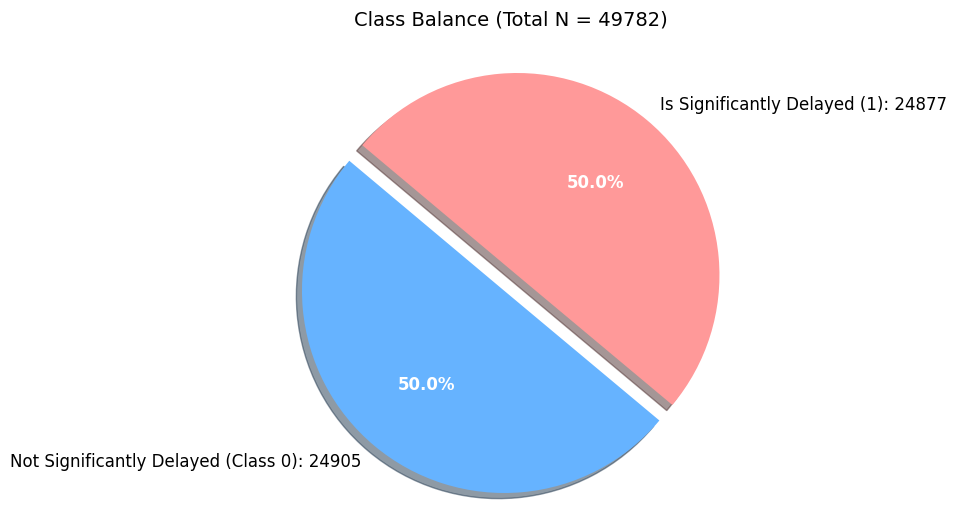

Negative Count: 24905
Positive Count: 24877
Class balance: 1.0011255376452144
Recommended scale_pos_weight: 1.00


In [ ]:
# 2. Extract counts (0 is Negative, 1 is Positive)
neg_count = dataset_cleaned_df[dataset_cleaned_df['target_binary'] == 0].shape[0]
pos_count = dataset_cleaned_df[dataset_cleaned_df['target_binary'] == 1].shape[0]

# Calculate percentages
total_count = neg_count + pos_count
neg_pct = (neg_count / total_count) * 100
pos_pct = (pos_count / total_count) * 100


# 1. Calculate counts and percentages
counts = dataset_cleaned_df['target_binary'].value_counts()
total = counts.sum()

# Create labels that include the raw count: e.g., "On-Time (0): 950"
labels = [f'{ "Not Significantly Delayed (Class 0)" if x == 0 else "Is Significantly Delayed (1)" }: {counts[x]}' for x in counts.index]
colors = ['#66b3ff', '#ff9999']

# 2. Plotting
plt.figure(figsize=(8, 6))
patches, texts, autotexts = plt.pie(
    counts, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    shadow=True, 
    startangle=140, 
    explode=(0.1, 0) if len(counts) > 1 else None,
    textprops={'fontsize': 12}
)

# Style the percentage text inside the pie to be bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

plt.title(f'Class Balance (Total N = {total})', fontsize=14, pad=20)
plt.axis('equal') 

# 3. Save to path
plt.savefig(f'{media_folder}/class_balance.png', bbox_inches='tight', dpi=300)
plt.show()


# 3. Store the ratio
# scale_pos_weight acts as a multiplier for the positive class gradient
if pos_count > 0:
    scale_pos_weight_value_train = neg_count / pos_count
else:
    scale_pos_weight_value_train = 1.0  # Fallback to neutral weight
    print("Warning: No positive instances found!")

print(f"Negative Count: {neg_count}")
print(f"Positive Count: {pos_count}")
print(f"Class balance: {neg_count / pos_count}")
print(f"Recommended scale_pos_weight: {scale_pos_weight_value_train:.2f}")

# Load Data (subset/fulll)

In [ ]:
# 1. Load the full dataset
df = pd.read_parquet(final_dataset_for_training_path)
if lei_subset and subset_dataset:
	data_df = df[(df['year'] >= 2024) & (df['month'] < 3)].copy()
	print(f"✅ Subset loaded. Rows: {len(data_df)}")
	print(f"Unique Years: {data_df['year'].unique()} | Unique Months: {data_df['month'].unique()}")
else:
	data_df = df.copy()
	print(f"✅ Full data loaded. Rows: {len(data_df)}")
	print(f"Unique Years: {data_df['year'].unique()} | Unique Months: {data_df['month'].unique()}")

✅ Subset loaded. Rows: 1416
Unique Years: [2024] | Unique Months: [1 2]


# 1_Class ORIGINAL

In [ ]:
# import sys
# import random
# import datetime
# import shap

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.stats as ss

# from datetime import date
# from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
# from xgboost import XGBClassifier
# from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

# sys.path.append('src')
# from plot_style import *

# def get_trajectory_slice(data, f_train_e=0.7, seed=30):
#     df = data
#     trajectories = list(set(df[['source', 'target']].itertuples(index=False, name=None)))
#     random.seed(seed)
#     train_size = int(f_train_e * len(trajectories))
#     random.shuffle(trajectories)
#     train_trajectories = set(trajectories[:train_size])
#     test_trajectories = set(trajectories[train_size:])
    
#     df_train = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(train_trajectories)].copy()
#     df_test = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(test_trajectories)].copy()
    
#     return df_train, df_test

# def df_to_XY(df, features, target='Significant Delay'):
#     X = df.loc[:, features].to_numpy()
#     y = df.loc[:, target].to_numpy()
#     return X, y

# def simultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#     if name is None:
#         name = ''.join([w[0] for w in features]) + '_simultaneous'
#     else:
#         name = name + '_simultaneous'
    
#     year_month_list = sorted(df_train['YearMonth'].unique())
#     res_df_test = df_test.copy()
#     res_df_test['simultaneous_pred'] = np.nan
#     res_df_test['simultaneous_null'] = np.nan
    
#     for year_month in tqdm(year_month_list):
#         X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#         ros = RandomUnderSampler()
#         X_train, y_train = ros.fit_resample(X_train, y_train)
#         X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
        
#         y_train_null = y_train.copy()
#         np.random.shuffle(y_train_null)
        
#         model = XGBClassifier(**best_params)
#         model.fit(X_train, y_train)
#         model_null = XGBClassifier(**best_params)
#         model_null.fit(X_train, y_train_null)
        
#         y_pred = model.predict(X_test)
#         y_pred_null = model_null.predict(X_test)
        
#         res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_pred'] = y_pred
#         res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_null'] = y_pred_null
    
#     if save:
#         res_df_test.to_csv(f'./results_XGB/{name}.csv', index=False)
    
#     return res_df_test

# def nonsimultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#     if name is None:
#         name = ''.join([w[0] for w in features]) + '_nonsimultaneous'
#     else:
#         name = name + '_nonsimultaneous'
    
#     year_month_list = sorted(df_test['YearMonth'].unique())
#     preds = []
    
#     for year_month_train in tqdm(year_month_list):
#         X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month_train], features)
#         ros = RandomUnderSampler()
#         X_train, y_train = ros.fit_resample(X_train, y_train)
        
#         y_train_null = y_train.copy()
#         np.random.shuffle(y_train_null)
        
#         model = XGBClassifier(**best_params)
#         model.fit(X_train, y_train)
#         model_null = XGBClassifier(**best_params)
#         model_null.fit(X_train, y_train_null)
        
#         for year_month_test in year_month_list:
#             if year_month_test < year_month_train:
#                 continue
#             X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month_test], features)
#             y_pred = model.predict(X_test)
#             y_null = model_null.predict(X_test)
#             preds.append([year_month_train, year_month_test, y_test, y_pred, y_null])
    
#     if save:
#         import pickle
#         with open(f'./results_XGB/{name}.pkl', 'wb') as f:
#             pickle.dump(preds, f)
    
#     return preds

# def all_shap_values(df_train, df_test, features, best_params, save=True, name=None):
#     if name is None:
#         name = ''.join([w[0] for w in features]) + '_SHAP'
#     else:
#         name = name + '_SHAP'
    
#     def get_temporal_order(shap_list):
#         importance_array = []
#         for shap_values in shap_list:
#             array = -np.abs(shap_values).mean(axis=0)
#             ranks = ss.rankdata(array)
#             importance_array.append(ranks)
#         return np.array(importance_array)

#     shap_values_list = []
#     test_list = []
#     year_month_list = sorted(df_test['YearMonth'].unique())
    
#     for year_month in tqdm(year_month_list):
#         X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#         ros = RandomUnderSampler()
#         X_train, y_train = ros.fit_resample(X_train, y_train)
#         X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
        
#         model = XGBClassifier(**best_params)
#         model.fit(X_train, y_train)
#         explainer = shap.TreeExplainer(model)
#         shap_values = explainer.shap_values(X_test)
        
#         test_list.append(pd.DataFrame(X_test, columns=features))
#         shap_values_list.append(shap_values)
    
#     if save:
#         import pickle
#         with open(f'./results_XGB/{name}.pkl', 'wb') as f:
#             pickle.dump((test_list, year_month_list, shap_values_list), f)
    
#     return test_list, year_month_list, shap_values_list

# def BTF(train, test):
#     name = 'NS_Classification_BTF'
#     features = ['CN', 'SA', 'JA', 'SO', 'HPI', 'HDI', 'LHNI', 'PA', 'AA', 'RA', 'LPI']
#     simultaneous_test(train, test, features, best_params, name=name)
#     nonsimultaneous_test(train, test, features, best_params, name=name)
#     all_shap_values(train, test, features, best_params, name=name)

# def WTF(train, test):
#     name = 'NS_Classification_WTF'
#     features = ['weighted_CN', 'weighted_SA', 'weighted_JA', 'weighted_SO', 'weighted_HPI', 
#                 'weighted_HDI', 'weighted_LHNI', 'weighted_PA', 'weighted_AA', 'weighted_RA', 'weighted_LPI']
#     simultaneous_test(train, test, features, best_params, name=name)
#     nonsimultaneous_test(train, test, features, best_params, name=name)
#     all_shap_values(train, test, features, best_params, name=name)

# def NCM(train, test):
#     name = 'NS_Classification_NCM'
#     features = ['source_closeness', 'target_closeness', 'source_degree', 'target_degree', 'source_strength', 'target_strength']
#     simultaneous_test(train, test, features, best_params, name=name)
#     nonsimultaneous_test(train, test, features, best_params, name=name)
#     all_shap_values(train, test, features, best_params, name=name)

# if __name__ == "__main__":
#     global best_params
#     best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
#                    'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
#                    'n_estimators': 625, 'objective': 'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

#     data_path = '/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/features/monthly_features_per_trajectory.csv'
#     data = pd.read_csv(data_path)
#     data['YearMonth'] = pd.to_datetime(data['YearMonth']).dt.to_period('M')
    
#     train, test = get_trajectory_slice(data)
#     BTF(train, test)
#     WTF(train, test)
#     NCM(train, test)

# 1_Class ADAPTED

In [ ]:
import sys
import random
import datetime
import shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

from datetime import date
from tqdm import tqdm
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

sys.path.append('src')
# from plot_style import *

def get_trajectory_slice(data, f_train_e=0.7, seed=30):
	df = data
	trajectories = list(set(df[['source', 'target']].itertuples(index=False, name=None)))
	random.seed(seed)
	train_size = int(f_train_e * len(trajectories))
	random.shuffle(trajectories)
	train_trajectories = set(trajectories[:train_size])
	test_trajectories = set(trajectories[train_size:])
	
	df_train = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(train_trajectories)].copy()
	df_test = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(test_trajectories)].copy()
	
	return df_train, df_test

def df_to_XY(df, features, target='target_binary'):
	X = df.loc[:, features].to_numpy()
	y = df.loc[:, target].to_numpy()
	return X, y

def simultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
	if name is None:
		name = ''.join([w[0] for w in features]) + '_simultaneous'
	else:
		name = name + '_simultaneous'
	
	year_month_list = sorted(df_train['YearMonth'].unique())
	res_df_test = df_test.copy()
	res_df_test['simultaneous_pred'] = np.nan
	res_df_test['simultaneous_null'] = np.nan
	
	for year_month in tqdm(year_month_list):
		X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
		ros = RandomUnderSampler()
		X_train, y_train = ros.fit_resample(X_train, y_train)
		X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
		
		y_train_null = y_train.copy()
		np.random.shuffle(y_train_null)
		
		model = XGBClassifier(**best_params)
		model.fit(X_train, y_train)
		model_null = XGBClassifier(**best_params)
		model_null.fit(X_train, y_train_null)
		
		y_pred = model.predict(X_test)
		y_pred_null = model_null.predict(X_test)
		
		res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_pred'] = y_pred
		res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_null'] = y_pred_null
	
	if save:
		res_df_test.to_csv(f'{results_xgb}/{name}.csv', index=False)
	
	return res_df_test

def nonsimultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
	if name is None:
		name = ''.join([w[0] for w in features]) + '_nonsimultaneous'
	else:
		name = name + '_nonsimultaneous'
	
	year_month_list = sorted(df_test['YearMonth'].unique())
	preds = []
	
	for year_month_train in tqdm(year_month_list):
		X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month_train], features)
		ros = RandomUnderSampler()
		X_train, y_train = ros.fit_resample(X_train, y_train)
		
		y_train_null = y_train.copy()
		np.random.shuffle(y_train_null)
		
		model = XGBClassifier(**best_params)
		model.fit(X_train, y_train)
		model_null = XGBClassifier(**best_params)
		model_null.fit(X_train, y_train_null)
		
		for year_month_test in year_month_list:
			if year_month_test < year_month_train:
				continue
			X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month_test], features)
			y_pred = model.predict(X_test)
			y_null = model_null.predict(X_test)
			preds.append([year_month_train, year_month_test, y_test, y_pred, y_null])
	
	if save:
		import pickle
		with open(f'{results_xgb}/{name}.pkl', 'wb') as f:
			pickle.dump(preds, f)
	
	return preds

def all_shap_values(df_train, df_test, features, best_params, save=True, name=None):
	if name is None:
		name = ''.join([w[0] for w in features]) + '_SHAP'
	else:
		name = name + '_SHAP'
	
	def get_temporal_order(shap_list):
		importance_array = []
		for shap_values in shap_list:
			array = -np.abs(shap_values).mean(axis=0)
			ranks = ss.rankdata(array)
			importance_array.append(ranks)
		return np.array(importance_array)

	shap_values_list = []
	test_list = []
	year_month_list = sorted(df_test['YearMonth'].unique())
	
	for year_month in tqdm(year_month_list):
		X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
		ros = RandomUnderSampler()
		X_train, y_train = ros.fit_resample(X_train, y_train)
		X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
		
		model = XGBClassifier(**best_params)
		model.fit(X_train, y_train)
		explainer = shap.TreeExplainer(model)
		shap_values = explainer.shap_values(X_test)
		
		test_list.append(pd.DataFrame(X_test, columns=features))
		shap_values_list.append(shap_values)
	
	if save:
		import pickle
		with open(f'{results_xgb}/{name}.pkl', 'wb') as f:
			pickle.dump((test_list, year_month_list, shap_values_list), f)
	
	return test_list, year_month_list, shap_values_list


def TOP(train, test):
	name = 'NS_I_TOP'
	features = topology_features
	simultaneous_test(train, test, features, best_params, name=name)
	nonsimultaneous_test(train, test, features, best_params, name=name)
	all_shap_values(train, test, features, best_params, name=name)

def WGT(train, test):
	name = 'NS_I_WGT'
	features = topology_weight_feature
	simultaneous_test(train, test, features, best_params, name=name)
	nonsimultaneous_test(train, test, features, best_params, name=name)
	all_shap_values(train, test, features, best_params, name=name)

def WTH(train, test):
	name = 'NS_I_WTH'
	features = weather_features
	simultaneous_test(train, test, features, best_params, name=name)
	nonsimultaneous_test(train, test, features, best_params, name=name)
	all_shap_values(train, test, features, best_params, name=name)

def OPS(train, test):
	name = 'NS_I_OPS'
	features = operational_features
	simultaneous_test(train, test, features, best_params, name=name)
	nonsimultaneous_test(train, test, features, best_params, name=name)
	all_shap_values(train, test, features, best_params, name=name)

def CAL(train, test):
	name = 'NS_I_CAL'
	features = calendar_features
	simultaneous_test(train, test, features, best_params, name=name)
	nonsimultaneous_test(train, test, features, best_params, name=name)
	all_shap_values(train, test, features, best_params, name=name)

def TW(train, test):
	name = 'NS_C_TW'
	features = topology_features + topology_weight_feature
	simultaneous_test(train, test, features, best_params, name=name)
	nonsimultaneous_test(train, test, features, best_params, name=name)
	all_shap_values(train, test, features, best_params, name=name)

def TWC(train, test):
	name = 'NS_C_TWC'
	features = topology_features + topology_weight_feature + calendar_features
	simultaneous_test(train, test, features, best_params, name=name)
	nonsimultaneous_test(train, test, features, best_params, name=name)
	all_shap_values(train, test, features, best_params, name=name)

def TWCW(train, test):
	name = 'NS_C_TWCW'
	features = topology_features + topology_weight_feature + calendar_features + weather_features
	simultaneous_test(train, test, features, best_params, name=name)
	nonsimultaneous_test(train, test, features, best_params, name=name)
	all_shap_values(train, test, features, best_params, name=name)

def TWCO(train, test):
	name = 'NS_C_TWCO'
	features = topology_features + topology_weight_feature + calendar_features + operational_features
	simultaneous_test(train, test, features, best_params, name=name)
	nonsimultaneous_test(train, test, features, best_params, name=name)
	all_shap_values(train, test, features, best_params, name=name)

def ALLF(train, test):
	name = 'NS_C_ALLF'
	features = topology_features + topology_weight_feature + calendar_features + operational_features + weather_features
	simultaneous_test(train, test, features, best_params, name=name)
	nonsimultaneous_test(train, test, features, best_params, name=name)
	all_shap_values(train, test, features, best_params, name=name)

if __name__ == "__main__":
	global best_params
	best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
				'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
				'n_estimators': 625, 'objective': 'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

	data = data_df
	data['YearMonth'] = pd.to_datetime(data['YearMonth'])    
	train, test = get_trajectory_slice(data)
	TOP(train, test)
	WGT(train, test)
	WTH(train, test)
	OPS(train, test)
	CAL(train, test)
	TW(train, test)
	TWC(train, test)
	TWCW(train, test)
	TWCO(train, test)
	ALLF(train, test)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:01<00:00,  1.59it/s]


# B_Class ORIGINAL

In [ ]:
# import sys
# import random
# import logging
# import numpy as np
# import pandas as pd
# from tqdm import tqdm
# from xgboost import XGBClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.linear_model import RidgeClassifier, LogisticRegression
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

# # Configure logging
# logging.basicConfig(level=logging.INFO)

# # Load data
# data_path = '/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/features/monthly_features_per_trajectory.csv'
# data = pd.read_csv(data_path)

# # Time-based split function to ensure each month has data in both sets
# def time_based_split(data, train_ratio=0.7):
#     train_data = []
#     test_data = []

#     for period in data['YearMonth'].unique():
#         period_data = data[data['YearMonth'] == period]
#         train_sample_count = int(len(period_data) * train_ratio)
        
#         period_train = period_data.sample(train_sample_count, random_state=42)
#         period_test = period_data.drop(period_train.index)
        
#         train_data.append(period_train)
#         test_data.append(period_test)

#     df_train = pd.concat(train_data)
#     df_test = pd.concat(test_data)

#     return df_train, df_test

# train, test = time_based_split(data)

# # Define the feature sets
# feature_sets = {
#     'TF': ['CN', 'SA', 'JA', 'SO', 'HPI', 'HDI', 'LHNI', 'PA', 'AA', 'RA', 'LPI'],
#     'WTF': ['weighted_CN', 'weighted_SA', 'weighted_JA', 'weighted_SO', 'weighted_HPI', 'weighted_HDI', 'weighted_LHNI', 'weighted_PA', 'weighted_AA', 'weighted_RA', 'weighted_LPI'],
#     'NCM': ['source_closeness', 'target_closeness', 'source_degree', 'target_degree', 'source_strength', 'target_strength']
# }

# # Define model training function
# def train_model(X_train, y_train, classifier, param_grid=None):
#     scaler = StandardScaler()
#     X_train = scaler.fit_transform(X_train)
    
#     if param_grid:
#         randomized_search = RandomizedSearchCV(
#             classifier, 
#             param_distributions=param_grid, 
#             n_iter=10, 
#             scoring='balanced_accuracy', 
#             n_jobs=-1, 
#             cv=10, 
#             random_state=RANDOM_SEED)
#         randomized_search.fit(X_train, y_train)
#         best_classifier = randomized_search.best_estimator_
#     else:
#         classifier.fit(X_train, y_train)
#         best_classifier = classifier
        
#     return best_classifier, scaler

# # Define evaluation function
# def evaluate_classifier(y_true, y_pred, y_proba=None):
#     if len(y_true) == 0 or len(y_pred) == 0:
#         return np.nan, np.nan, np.nan  # Return NaN if arrays are empty

#     balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
#     f1 = f1_score(y_true, y_pred)
#     if y_proba is not None and len(y_proba) == len(y_true):
#         auc = roc_auc_score(y_true, y_proba)
#     else:
#         auc = np.nan  # Return NaN if probabilities are not available or not the same length
#     return balanced_accuracy, f1, auc

# # Define function to convert dataframe to X, y
# def df_to_XY(df, features, target='Significant Delay'):
#     X = df[features].to_numpy()
#     y = df[target].astype(int).to_numpy()
#     return X, y

# # Define Simultaneous Testing Function
# def simultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
#     year_month_list = df_train['YearMonth'].unique()
#     res_df_test = df_test.copy()
#     res_df_test[f'{name}_pred'] = np.nan
#     res_df_test[f'{name}_proba'] = np.nan

#     all_y_true = []
#     all_y_pred = []
#     all_y_proba = []

#     for year_month in tqdm(year_month_list):
#         train_subset = df_train[df_train['YearMonth'] == year_month]
#         test_subset = df_test[df_test['YearMonth'] == year_month]

#         X_train, y_train = df_to_XY(train_subset, features)
#         X_test, y_test = df_to_XY(test_subset, features)

#         if len(X_train) == 0 or len(X_test) == 0:
#             logging.warning(f"Skipping YearMonth {year_month} due to empty training or testing data.")
#             continue

#         model, scaler = train_model(X_train, y_train, classifier, param_grid)
#         X_test = scaler.transform(X_test)

#         y_pred = model.predict(X_test)
#         y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

#         res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_pred'] = y_pred
#         if y_proba is not None:
#             res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_proba'] = y_proba

#         # Store intermediate results
#         all_y_true.extend(y_test)
#         all_y_pred.extend(y_pred)
#         if y_proba is not None:
#             all_y_proba.extend(y_proba)

#     if len(all_y_true) > 0 and len(all_y_pred) > 0:
#         if all_y_proba:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
#         else:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
#     else:
#         balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

#     print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

#     res_df_test.to_csv(f'/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/results_classifiers/{name}_results.csv', index=False)
#     return res_df_test, all_y_true, all_y_pred, all_y_proba

# # Define Non-Simultaneous Testing Function
# def nonsimultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
#     year_month_list = df_train['YearMonth'].unique()
#     results = []

#     for i, train_period in enumerate(tqdm(year_month_list)):
#         train_subset = df_train[df_train['YearMonth'] == train_period]
#         X_train, y_train = df_to_XY(train_subset, features)

#         if len(y_train) == 0:
#             logging.warning(f"Skipping train_period {train_period} due to empty training data.")
#             continue

#         model, scaler = train_model(X_train, y_train, classifier, param_grid)

#         for test_period in year_month_list[i:]:
#             test_subset = df_test[df_test['YearMonth'] == test_period]
#             X_test, y_test = df_to_XY(test_subset, features)

#             if len(y_test) == 0:
#                 logging.warning(f"Skipping test_period {test_period} due to empty testing data.")
#                 continue

#             X_test = scaler.transform(X_test)
#             y_pred = model.predict(X_test)
#             y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
#             results.append((train_period, test_period, y_test.tolist(), y_pred.tolist(), y_proba.tolist() if y_proba is not None else []))

#     results_df = pd.DataFrame(results, columns=['TrainPeriod', 'TestPeriod', 'TrueLabels', 'Predictions', 'Probabilities'])
#     results_df.to_csv(f'/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/results_classifiers/{name}_nonsimultaneous_results.csv', index=False)

#     all_y_true = [label for result in results for label in result[2]]
#     all_y_pred = [pred for result in results for pred in result[3]]
#     all_y_proba = [proba for result in results for proba in result[4]]

#     if len(all_y_true) > 0 and len(all_y_pred) > 0:
#         if all_y_proba:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
#         else:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
#     else:
#         balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

#     print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

#     return results_df, all_y_true, all_y_pred, all_y_proba

# # Define parameter grids for each classifier
# param_grids = {
#     'GradientBoostingClassifier': {
#         'n_estimators': [50, 100, 200, 300],
#         'learning_rate': [0.01, 0.05, 0.1, 0.2],
#         'max_depth': [3, 5, 7, 9],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#         'max_features': ['sqrt', 'log2']
#     },
#     'AdaBoostClassifier': {
#         'n_estimators': [50, 100, 200, 400],
#         'learning_rate': [0.01, 0.1, 0.5, 1.0]
#     },
#     'LogisticRegression': {
#         'C': [0.001, 0.01, 0.1, 1, 10, 100],
#         'penalty': ['l1', 'l2', 'elasticnet'],
#         'solver': ['liblinear', 'saga']
#     },
#     'RandomForestClassifier': {
#         'n_estimators': [100, 200, 500, 1000],
#         'max_features': ['auto', 'sqrt', 'log2'],
#         'max_depth': [10, 20, 30, None],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#         'bootstrap': [True, False]
#     },
#     'DecisionTreeClassifier': {
#         'max_features': ['auto', 'sqrt', 'log2'],
#         'max_depth': [10, 20, 30, None],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#         'criterion': ['gini', 'entropy']
#     }
# }

# # Specific parameters for XGBoost
# best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
#            'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
#            'n_estimators': 625, 'objective':'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

# # Include classifiers dictionary with XGBoost
# classifiers = {
#     'GradientBoostingClassifier': GradientBoostingClassifier(),
#     'AdaBoostClassifier': AdaBoostClassifier(),
#     'LogisticRegression': LogisticRegression(),
#     'RandomForestClassifier': RandomForestClassifier(),
#     'DecisionTreeClassifier': DecisionTreeClassifier(),
#     'XGBClassifier': XGBClassifier(**best_params),
# }

# # Run simultaneous and non-simultaneous testing for each classifier and each feature set
# for feature_set_name, feature_set in feature_sets.items():
#     for name, classifier in classifiers.items():
#         param_grid = param_grids.get(name, None)
#         print(f"Running simultaneous test for {name} with feature set {feature_set_name}...")
#         simultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')
        
#         print(f"Running non-simultaneous test for {name} with feature set {feature_set_name}...")
#         nonsimultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')

# B_Class ADAPTED

In [ ]:
import sys
import random
import logging
import numpy as np
import pandas as pd
from tqdm import tqdm
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

# Configure logging
logging.basicConfig(level=logging.INFO)

# Load data
data = data_df

# Time-based split function to ensure each month has data in both sets
def time_based_split(data, train_ratio=0.7):
	train_data = []
	test_data = []

	for period in data['YearMonth'].unique():
		period_data = data[data['YearMonth'] == period]
		train_sample_count = int(len(period_data) * train_ratio)
		
		period_train = period_data.sample(train_sample_count, random_state=42)
		period_test = period_data.drop(period_train.index)
		
		train_data.append(period_train)
		test_data.append(period_test)

	df_train = pd.concat(train_data)
	df_test = pd.concat(test_data)

	return df_train, df_test

train, test = time_based_split(data)

# Define the feature sets
feature_sets = {
	'TOP': topology_features,
	'WGT': topology_weight_feature,
	'WTH': weather_features,
	'OPS': operational_features,
	'CAL': calendar_features,
	'TW':  topology_features + topology_weight_feature,
	
	# Combined feature sets 
	'TWC':  topology_features + topology_weight_feature + calendar_features,
	'TWCW': topology_features + topology_weight_feature + calendar_features + weather_features,
	'TWCO': topology_features + topology_weight_feature + calendar_features + operational_features,
	'ALLF': topology_features + topology_weight_feature + calendar_features + operational_features + weather_features
}

# Define model training function
def train_model(X_train, y_train, classifier, param_grid=None):
	scaler = StandardScaler()
	X_train = scaler.fit_transform(X_train)
	
	# Dynamically calculate and set scale_pos_weight for XGBoost
	if isinstance(classifier, XGBClassifier):
		neg_count = np.sum(y_train == 0)
		pos_count = np.sum(y_train == 1)
		
		if pos_count > 0:
			spw = neg_count / pos_count
			classifier.set_params(scale_pos_weight=spw)
			logging.info(f" Set XGBoost scale_pos_weight to {spw:.2f}")
			
	if param_grid:
		randomized_search = RandomizedSearchCV(
			classifier, 
			param_distributions=param_grid, 
			n_iter=10, 
			scoring='balanced_accuracy', 
			n_jobs=-1, 
			cv=10, 
			random_state=RANDOM_SEED)
		randomized_search.fit(X_train, y_train)
		best_classifier = randomized_search.best_estimator_
	else:
		classifier.fit(X_train, y_train)
		best_classifier = classifier
		
	return best_classifier, scaler

# Define evaluation function
def evaluate_classifier(y_true, y_pred, y_proba=None):
	if len(y_true) == 0 or len(y_pred) == 0:
		return np.nan, np.nan, np.nan  # Return NaN if arrays are empty

	balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
	f1 = f1_score(y_true, y_pred)
	if y_proba is not None and len(y_proba) == len(y_true):
		auc = roc_auc_score(y_true, y_proba)
	else:
		auc = np.nan  # Return NaN if probabilities are not available or not the same length
	return balanced_accuracy, f1, auc

# Define function to convert dataframe to X, y
def df_to_XY(df, features, target='target_binary'):
	X = df[features].to_numpy()
	y = df[target].astype(int).to_numpy()
	return X, y

# Define Simultaneous Testing Function
def simultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
	year_month_list = df_train['YearMonth'].unique()
	res_df_test = df_test.copy()
	res_df_test[f'{name}_pred'] = np.nan
	res_df_test[f'{name}_proba'] = np.nan

	all_y_true = []
	all_y_pred = []
	all_y_proba = []

	for year_month in tqdm(year_month_list):
		train_subset = df_train[df_train['YearMonth'] == year_month]
		test_subset = df_test[df_test['YearMonth'] == year_month]

		X_train, y_train = df_to_XY(train_subset, features)
		X_test, y_test = df_to_XY(test_subset, features)

		if len(X_train) == 0 or len(X_test) == 0:
			logging.warning(f"Skipping YearMonth {year_month} due to empty training or testing data.")
			continue

		model, scaler = train_model(X_train, y_train, classifier, param_grid)
		X_test = scaler.transform(X_test)

		y_pred = model.predict(X_test)
		y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

		res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_pred'] = y_pred
		if y_proba is not None:
			res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_proba'] = y_proba

		# Store intermediate results
		all_y_true.extend(y_test)
		all_y_pred.extend(y_pred)
		if y_proba is not None:
			all_y_proba.extend(y_proba)

	if len(all_y_true) > 0 and len(all_y_pred) > 0:
		if all_y_proba:
			balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
		else:
			balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
	else:
		balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

	print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

	res_df_test.to_csv(f'{results_classifiers}/{name}_results.csv', index=False)
	return res_df_test, all_y_true, all_y_pred, all_y_proba

# Define Non-Simultaneous Testing Function
def nonsimultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
	year_month_list = df_train['YearMonth'].unique()
	results = []

	for i, train_period in enumerate(tqdm(year_month_list)):
		train_subset = df_train[df_train['YearMonth'] == train_period]
		X_train, y_train = df_to_XY(train_subset, features)

		if len(y_train) == 0:
			logging.warning(f"Skipping train_period {train_period} due to empty training data.")
			continue

		model, scaler = train_model(X_train, y_train, classifier, param_grid)

		for test_period in year_month_list[i:]:
			test_subset = df_test[df_test['YearMonth'] == test_period]
			X_test, y_test = df_to_XY(test_subset, features)

			if len(y_test) == 0:
				logging.warning(f"Skipping test_period {test_period} due to empty testing data.")
				continue

			X_test = scaler.transform(X_test)
			y_pred = model.predict(X_test)
			y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
			results.append((train_period, test_period, y_test.tolist(), y_pred.tolist(), y_proba.tolist() if y_proba is not None else []))

	results_df = pd.DataFrame(results, columns=['TrainPeriod', 'TestPeriod', 'TrueLabels', 'Predictions', 'Probabilities'])
	results_df.to_csv(f'{results_classifiers}/{name}_nonsimultaneous_results.csv', index=False)

	all_y_true = [label for result in results for label in result[2]]
	all_y_pred = [pred for result in results for pred in result[3]]
	all_y_proba = [proba for result in results for proba in result[4]]

	if len(all_y_true) > 0 and len(all_y_pred) > 0:
		if all_y_proba:
			balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
		else:
			balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
	else:
		balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

	print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

	return results_df, all_y_true, all_y_pred, all_y_proba

# Define parameter grids for each classifier
param_grids = {
	'LogisticRegression': {
		'C': [0.001, 0.01, 0.1, 1, 10, 100],
		'penalty': ['l1', 'l2', 'elasticnet'],
		'solver': ['liblinear', 'saga']
	},
	'RandomForestClassifier': {
		'n_estimators': [100, 200, 500, 1000],
		'max_features': ['auto', 'sqrt', 'log2'],
		'max_depth': [10, 20, 30, None],
		'min_samples_split': [2, 5, 10],
		'min_samples_leaf': [1, 2, 4],
		'bootstrap': [True, False]
	},
	'XGBClassifier':{
		'max_depth': [3, 5, 7],
		'learning_rate': [0.01, 0.1, 0.3],      
		'n_estimators': [100, 200, 300],
		'subsample': [0.6, 0.8, 1.0],
		'colsample_bytree': [0.6, 0.8, 1.0],
	},
	'LGBMClassifier': {
		'max_depth': [-1, 3, 5, 7],          
		'num_leaves': [31, 50, 100], 
		'learning_rate': [0.01, 0.1, 0.3], 
		'n_estimators': [100, 200, 300],     
		'subsample': [0.6, 0.8, 1.0],        
		'colsample_bytree': [0.6, 0.8, 1.0],
	},
	'GradientBoostingClassifier': {
		'n_estimators': [50, 100, 200, 300],
		'learning_rate': [0.01, 0.05, 0.1, 0.2],
		'max_depth': [3, 5, 7, 9],
		'min_samples_split': [2, 5, 10],
		'min_samples_leaf': [1, 2, 4],
		'max_features': ['sqrt', 'log2']
	},
	'AdaBoostClassifier': {
		'n_estimators': [50, 100, 200, 400],
		'learning_rate': [0.01, 0.1, 0.5, 1.0]
	},
	'DecisionTreeClassifier': {
		'max_features': ['auto', 'sqrt', 'log2'],
		'max_depth': [10, 20, 30, None],
		'min_samples_split': [2, 5, 10],
		'min_samples_leaf': [1, 2, 4],
		'criterion': ['gini', 'entropy']
	}
}

# Specific parameters for XGBoost
best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
		'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
		'n_estimators': 625, 'objective':'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

# Include classifiers dictionary with XGBoost
classifiers = {
	'LogisticRegression': LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced', max_iter=1000),
	'RandomForestClassifier': RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced', verbose=0),
	'XGBClassifier': XGBClassifier(random_state=RANDOM_SEED, verbosity=0), # Set scale pos weight dynamically in train_model
	'LGBMClassifier': LGBMClassifier(random_state=RANDOM_SEED, class_weight='balanced', verbose=-1)
	# 'GradientBoostingClassifier': GradientBoostingClassifier(),
	# 'AdaBoostClassifier': AdaBoostClassifier(),
	# 'DecisionTreeClassifier': DecisionTreeClassifier(),
}

# Run simultaneous and non-simultaneous testing for each classifier and each feature set
for feature_set_name, feature_set in feature_sets.items():
	for name, classifier in classifiers.items():
		param_grid = param_grids.get(name, None)
		print(f"Running simultaneous test for {name} with feature set {feature_set_name}...")
		simultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')
		
		print(f"Running non-simultaneous test for {name} with feature set {feature_set_name}...")
		nonsimultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')

Running simultaneous test for XGBClassifier with feature set TOP...


  0%|          | 0/2 [00:00<?, ?it/s]INFO:root: Set XGBoost scale_pos_weight to 0.31


100%|██████████| 2/2 [00:10<00:00,  5.03s/it]


XGBClassifier_TOP - Balanced Accuracy: 0.6711, F1 Score: 0.7816, AUC: 0.7053
Running non-simultaneous test for XGBClassifier with feature set TOP...


100%|██████████| 2/2 [00:05<00:00,  2.95s/it]


...

XGBClassifier_WTH - Balanced Accuracy: 0.6309, F1 Score: 0.7648, AUC: 0.6831
Running non-simultaneous test for XGBClassifier with feature set WTH...


100%|██████████| 2/2 [00:06<00:00,  3.25s/it]


XGBClassifier_WTH - Balanced Accuracy: 0.5773, F1 Score: 0.7862, AUC: 0.5964
Running simultaneous test for LGBMClassifier with feature set WTH...


  0%|          | 0/2 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# import sys
# import random
# import logging
# import numpy as np
# import pandas as pd
# from tqdm import tqdm
# from xgboost import XGBClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.linear_model import RidgeClassifier, LogisticRegression
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

# # Configure logging
# logging.basicConfig(level=logging.INFO)

# # Load data
# data_path = final_dataset_for_training_path
# data = pd.read_parquet(data_path)

# # Time-based split function to ensure each month has data in both sets
# def time_based_split(data, train_ratio=0.7):
#     train_data = []
#     test_data = []

#     for period in data['YearMonth'].unique():
#         period_data = data[data['YearMonth'] == period]
#         train_sample_count = int(len(period_data) * train_ratio)
        
#         period_train = period_data.sample(train_sample_count, random_state=42)
#         period_test = period_data.drop(period_train.index)
        
#         train_data.append(period_train)
#         test_data.append(period_test)

#     df_train = pd.concat(train_data)
#     df_test = pd.concat(test_data)

#     return df_train, df_test

# train, test = time_based_split(data)

# # Define the feature sets
# feature_sets = {
#     'TOP': topology_features,
#     'WGT': topology_weight_feature,
#     'WTH': weather_features,
#     'OPS': operational_features,
#     'CAL': calendar_features,
#     'TW':  topology_features + topology_weight_feature,
    
#     # Combined feature sets 
#     'TWC':  topology_features + topology_weight_feature + calendar_features,
#     'TWCW': topology_features + topology_weight_feature + calendar_features + weather_features,
#     'TWCO': topology_features + topology_weight_feature + calendar_features + operational_features,
#     'ALLF': topology_features + topology_weight_feature + calendar_features + operational_features + weather_features
# }

# # Define model training function
# def train_model(X_train, y_train, classifier, param_grid=None):
#     scaler = StandardScaler()
#     X_train = scaler.fit_transform(X_train)
    
#     if param_grid:
#         randomized_search = RandomizedSearchCV(
#             classifier, 
#             param_distributions=param_grid, 
#             n_iter=10, 
#             scoring='balanced_accuracy', 
#             n_jobs=-1, 
#             cv=10, 
#             random_state=RANDOM_SEED)
#         randomized_search.fit(X_train, y_train)
#         best_classifier = randomized_search.best_estimator_
#     else:
#         classifier.fit(X_train, y_train)
#         best_classifier = classifier
        
#     return best_classifier, scaler

# # Define evaluation function
# def evaluate_classifier(y_true, y_pred, y_proba=None):
#     if len(y_true) == 0 or len(y_pred) == 0:
#         return np.nan, np.nan, np.nan  # Return NaN if arrays are empty

#     balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
#     f1 = f1_score(y_true, y_pred)
#     if y_proba is not None and len(y_proba) == len(y_true):
#         auc = roc_auc_score(y_true, y_proba)
#     else:
#         auc = np.nan  # Return NaN if probabilities are not available or not the same length
#     return balanced_accuracy, f1, auc

# # Define function to convert dataframe to X, y
# def df_to_XY(df, features, target='target_binary'):
#     X = df[features].to_numpy()
#     y = df[target].astype(int).to_numpy()
#     return X, y

# # Define Simultaneous Testing Function
# def simultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
#     year_month_list = df_train['YearMonth'].unique()
#     res_df_test = df_test.copy()
#     res_df_test[f'{name}_pred'] = np.nan
#     res_df_test[f'{name}_proba'] = np.nan

#     all_y_true = []
#     all_y_pred = []
#     all_y_proba = []

#     for year_month in tqdm(year_month_list):
#         train_subset = df_train[df_train['YearMonth'] == year_month]
#         test_subset = df_test[df_test['YearMonth'] == year_month]

#         X_train, y_train = df_to_XY(train_subset, features)
#         X_test, y_test = df_to_XY(test_subset, features)

#         if len(X_train) == 0 or len(X_test) == 0:
#             logging.warning(f"Skipping YearMonth {year_month} due to empty training or testing data.")
#             continue

#         model, scaler = train_model(X_train, y_train, classifier, param_grid)
#         X_test = scaler.transform(X_test)

#         y_pred = model.predict(X_test)
#         y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

#         res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_pred'] = y_pred
#         if y_proba is not None:
#             res_df_test.loc[res_df_test['YearMonth'] == year_month, f'{name}_proba'] = y_proba

#         # Store intermediate results
#         all_y_true.extend(y_test)
#         all_y_pred.extend(y_pred)
#         if y_proba is not None:
#             all_y_proba.extend(y_proba)

#     if len(all_y_true) > 0 and len(all_y_pred) > 0:
#         if all_y_proba:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
#         else:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
#     else:
#         balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

#     print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

#     res_df_test.to_csv(f'{results_classifiers}/{name}_results.csv', index=False)
#     return res_df_test, all_y_true, all_y_pred, all_y_proba

# # Define Non-Simultaneous Testing Function
# def nonsimultaneous_test(df_train, df_test, features, classifier, param_grid=None, name=None):
#     year_month_list = df_train['YearMonth'].unique()
#     results = []

#     for i, train_period in enumerate(tqdm(year_month_list)):
#         train_subset = df_train[df_train['YearMonth'] == train_period]
#         X_train, y_train = df_to_XY(train_subset, features)

#         if len(y_train) == 0:
#             logging.warning(f"Skipping train_period {train_period} due to empty training data.")
#             continue

#         model, scaler = train_model(X_train, y_train, classifier, param_grid)

#         for test_period in year_month_list[i:]:
#             test_subset = df_test[df_test['YearMonth'] == test_period]
#             X_test, y_test = df_to_XY(test_subset, features)

#             if len(y_test) == 0:
#                 logging.warning(f"Skipping test_period {test_period} due to empty testing data.")
#                 continue

#             X_test = scaler.transform(X_test)
#             y_pred = model.predict(X_test)
#             y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
#             results.append((train_period, test_period, y_test.tolist(), y_pred.tolist(), y_proba.tolist() if y_proba is not None else []))

#     results_df = pd.DataFrame(results, columns=['TrainPeriod', 'TestPeriod', 'TrueLabels', 'Predictions', 'Probabilities'])
#     results_df.to_csv(f'{results_classifiers}/{name}_nonsimultaneous_results.csv', index=False)

#     all_y_true = [label for result in results for label in result[2]]
#     all_y_pred = [pred for result in results for pred in result[3]]
#     all_y_proba = [proba for result in results for proba in result[4]]

#     if len(all_y_true) > 0 and len(all_y_pred) > 0:
#         if all_y_proba:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
#         else:
#             balanced_accuracy, f1, auc = evaluate_classifier(np.array(all_y_true), np.array(all_y_pred))
#     else:
#         balanced_accuracy, f1, auc = np.nan, np.nan, np.nan

#     print(f"{name} - Balanced Accuracy: {balanced_accuracy:.4f}, F1 Score: {f1:.4f}, AUC: {auc:.4f}")

#     return results_df, all_y_true, all_y_pred, all_y_proba

# # Define parameter grids for each classifier
# param_grids = {
#         'LogisticRegression': {
#         'C': [0.001, 0.01, 0.1, 1, 10, 100],
#         'penalty': ['l1', 'l2', 'elasticnet'],
#         'solver': ['liblinear', 'saga']
#     },
#         'RandomForestClassifier': {
#         'n_estimators': [100, 200, 500, 1000],
#         'max_features': ['auto', 'sqrt', 'log2'],
#         'max_depth': [10, 20, 30, None],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#         'bootstrap': [True, False]
# 	},
#     # 'GradientBoostingClassifier': {
#     #     'n_estimators': [50, 100, 200, 300],
#     #     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     #     'max_depth': [3, 5, 7, 9],
#     #     'min_samples_split': [2, 5, 10],
#     #     'min_samples_leaf': [1, 2, 4],
#     #     'max_features': ['sqrt', 'log2']
#     # },
#     # 'AdaBoostClassifier': {
#     #     'n_estimators': [50, 100, 200, 400],
#     #     'learning_rate': [0.01, 0.1, 0.5, 1.0]
#     # },
    
#     # 'DecisionTreeClassifier': {
#     #     'max_features': ['auto', 'sqrt', 'log2'],
#     #     'max_depth': [10, 20, 30, None],
#     #     'min_samples_split': [2, 5, 10],
#     #     'min_samples_leaf': [1, 2, 4],
#     #     'criterion': ['gini', 'entropy']
#     # }
# }

# # Specific parameters for XGBoost
# best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
#            'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
#            'n_estimators': 625, 'objective':'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

# # Include classifiers dictionary with XGBoost
# classifiers = {
#     'LogisticRegression': LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced' ),
#     'RandomForestClassifier': RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced'),
#     # 'DecisionTreeClassifier': DecisionTreeClassifier(),
# 	# 'GradientBoostingClassifier': GradientBoostingClassifier(),
#     # 'AdaBoostClassifier': AdaBoostClassifier(),
#     'XGBClassifier': XGBClassifier(**best_params, random_state=RANDOM_SEED,class_weight),
#     'LGBMClassifier': LGBMClassifier(random_state=RANDOM_SEED, class_weight='balanced')
# }

# # Run simultaneous and non-simultaneous testing for each classifier and each feature set
# for feature_set_name, feature_set in feature_sets.items():
#     for name, classifier in classifiers.items():
#         param_grid = param_grids.get(name, None)
#         print(f"Running simultaneous test for {name} with feature set {feature_set_name}...")
#         simultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')
        
#         print(f"Running non-simultaneous test for {name} with feature set {feature_set_name}...")
#         nonsimultaneous_test(train, test, feature_set, classifier, param_grid, f'{name}_{feature_set_name}')

Running simultaneous test for GradientBoostingClassifier with feature set TOP...


  0%|          | 0/72 [00:32<?, ?it/s]


KeyboardInterrupt: 

# PRIOR WORK |

Lei's/Merels

1. Find best parameters per model, RandomizedSearchCV=10 TimeSeriesSplit n_split = data of years in training, on parameter grid (full train dataset)

2. Data Splitting: The "Trajectory" Split
Function: get_trajectory_slice

What they did: Instead of randomly splitting rows (e.g., taking 70% of all data points), they split by Trajectory (Source-Target pairs).

Train Set: All data for 70% of the routes (e.g., Amsterdam -> Utrecht).
Test Set: All data for the other 30% of the routes (e.g., Rotterdam -> Hague).

3. Feature Grouping (Ablation Study)
Functions: 

BTF (Binary Topological Features): Simple connection metrics (Common Neighbors, Jaccard).
WTF (Weighted Topological Features): Connection metrics that consider weight/intensity.
NCM (Node Centrality Metrics): Importance of the stations (Degree, Closeness).

4. Experiment A: Simultaneous Testing (The "Now" Test)
Function: simultaneous_test
Loop through every time horizon T. For each T, train on 70% of the edges in T and utilize 30% as test. This means for our hourly dataset too many -> can we randomly sample few hours in the dataset to test this instead of every hour? To check features without any temporal aspect. It eliminates the variable of time. If the model fails here, the features are useless. 
-> do we need randomundersampler?

model_null: Trained "dummy" on shuffled data. Real model atleast should be better than this random chance.

5. Experiment B: Non-Simultaneous Testing (The "Future" Test)
Function: nonsimultaneous_test

Train on Month X.
Test on Month X, Month X+1, Month X+2...

Testing Generalization across time

Can a model trained on January's network topology predict delays in March?

If metrics drop -> model drift, needs retraining. Tests robustness over time

6. Explainability: SHAP Analysis (on test sets) -> HOW it works
Function: all_shap_values

Workflow
Tune: Find best hyperparameters.
Split: Separate data by Route (Space).
Group: Pick a feature set (e.g., BTF).
Validate (Space, stimulous): Test on new routes in the same month.
Validate (Time, non stimulous): Test on new routes in future months.
Explain: Calculate SHAP to rank feature importance.

## Lei/Merel reference code


In [ ]:
# import sys
# import random
# import datetime
# import shap

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.stats as ss

# from datetime import date
# from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
# from xgboost import XGBClassifier
# from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

# sys.path.append('src')
# from plot_style import *

# def get_trajectory_slice(data, f_train_e=0.7, seed=30):
#	 df = data
#	 trajectories = list(set(df[['source', 'target']].itertuples(index=False, name=None)))
#	 random.seed(seed)
#	 train_size = int(f_train_e * len(trajectories))
#	 random.shuffle(trajectories)
#	 train_trajectories = set(trajectories[:train_size])
#	 test_trajectories = set(trajectories[train_size:])
	
#	 df_train = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(train_trajectories)].copy()
#	 df_test = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(test_trajectories)].copy()
	
#	 return df_train, df_test

# def df_to_XY(df, features, target='Significant Delay'):
#	 X = df.loc[:, features].to_numpy()
#	 y = df.loc[:, target].to_numpy()
#	 return X, y

# def simultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#	 if name is None:
#		 name = ''.join([w[0] for w in features]) + '_simultaneous'
#	 else:
#		 name = name + '_simultaneous'
	
#	 year_month_list = sorted(df_train['YearMonth'].unique())
#	 res_df_test = df_test.copy()
#	 res_df_test['simultaneous_pred'] = np.nan
#	 res_df_test['simultaneous_null'] = np.nan
	
#	 for year_month in tqdm(year_month_list):
#		 X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#		 ros = RandomUnderSampler()
#		 X_train, y_train = ros.fit_resample(X_train, y_train)
#		 X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
		
#		 y_train_null = y_train.copy()
#		 np.random.shuffle(y_train_null)
		
#		 model = XGBClassifier(**best_params)
#		 model.fit(X_train, y_train)
#		 model_null = XGBClassifier(**best_params)
#		 model_null.fit(X_train, y_train_null)
		
#		 y_pred = model.predict(X_test)
#		 y_pred_null = model_null.predict(X_test)
		
#		 res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_pred'] = y_pred
#		 res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_null'] = y_pred_null
	
#	 if save:
#		 res_df_test.to_csv(f'./results_XGB/{name}.csv', index=False)
	
#	 return res_df_test

# def nonsimultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#	 if name is None:
#		 name = ''.join([w[0] for w in features]) + '_nonsimultaneous'
#	 else:
#		 name = name + '_nonsimultaneous'
	
#	 year_month_list = sorted(df_test['YearMonth'].unique())
#	 preds = []
	
#	 for year_month_train in tqdm(year_month_list):
#		 X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month_train], features)
#		 ros = RandomUnderSampler()
#		 X_train, y_train = ros.fit_resample(X_train, y_train)
		
#		 y_train_null = y_train.copy()
#		 np.random.shuffle(y_train_null)
		
#		 model = XGBClassifier(**best_params)
#		 model.fit(X_train, y_train)
#		 model_null = XGBClassifier(**best_params)
#		 model_null.fit(X_train, y_train_null)
		
#		 for year_month_test in year_month_list:
#			 if year_month_test < year_month_train:
#				 continue
#			 X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month_test], features)
#			 y_pred = model.predict(X_test)
#			 y_null = model_null.predict(X_test)
#			 preds.append([year_month_train, year_month_test, y_test, y_pred, y_null])
	
#	 if save:
#		 import pickle
#		 with open(f'./results_XGB/{name}.pkl', 'wb') as f:
#			 pickle.dump(preds, f)
	
#	 return preds

# def all_shap_values(df_train, df_test, features, best_params, save=True, name=None):
#	 if name is None:
#		 name = ''.join([w[0] for w in features]) + '_SHAP'
#	 else:
#		 name = name + '_SHAP'
	
#	 def get_temporal_order(shap_list):
#		 importance_array = []
#		 for shap_values in shap_list:
#			 array = -np.abs(shap_values).mean(axis=0)
#			 ranks = ss.rankdata(array)
#			 importance_array.append(ranks)
#		 return np.array(importance_array)

#	 shap_values_list = []
#	 test_list = []
#	 year_month_list = sorted(df_test['YearMonth'].unique())
	
#	 for year_month in tqdm(year_month_list):
#		 X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#		 ros = RandomUnderSampler()
#		 X_train, y_train = ros.fit_resample(X_train, y_train)
#		 X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
		
#		 model = XGBClassifier(**best_params)
#		 model.fit(X_train, y_train)
#		 explainer = shap.TreeExplainer(model)
#		 shap_values = explainer.shap_values(X_test)
		
#		 test_list.append(pd.DataFrame(X_test, columns=features))
#		 shap_values_list.append(shap_values)
	
#	 if save:
#		 import pickle
#		 with open(f'./results_XGB/{name}.pkl', 'wb') as f:
#			 pickle.dump((test_list, year_month_list, shap_values_list), f)
	
#	 return test_list, year_month_list, shap_values_list

# def BTF(train, test):
#	 name = 'NS_Classification_BTF'
#	 features = ['CN', 'SA', 'JA', 'SO', 'HPI', 'HDI', 'LHNI', 'PA', 'AA', 'RA', 'LPI']
#	 simultaneous_test(train, test, features, best_params, name=name)
#	 nonsimultaneous_test(train, test, features, best_params, name=name)
#	 all_shap_values(train, test, features, best_params, name=name)

# def WTF(train, test):
#	 name = 'NS_Classification_WTF'
#	 features = ['weighted_CN', 'weighted_SA', 'weighted_JA', 'weighted_SO', 'weighted_HPI', 
#				 'weighted_HDI', 'weighted_LHNI', 'weighted_PA', 'weighted_AA', 'weighted_RA', 'weighted_LPI']
#	 simultaneous_test(train, test, features, best_params, name=name)
#	 nonsimultaneous_test(train, test, features, best_params, name=name)
#	 all_shap_values(train, test, features, best_params, name=name)

# def NCM(train, test):
#	 name = 'NS_Classification_NCM'
#	 features = ['source_closeness', 'target_closeness', 'source_degree', 'target_degree', 'source_strength', 'target_strength']
#	 simultaneous_test(train, test, features, best_params, name=name)
#	 nonsimultaneous_test(train, test, features, best_params, name=name)
#	 all_shap_values(train, test, features, best_params, name=name)

# if __name__ == "__main__":
#	 global best_params
#	 best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
#					'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
#					'n_estimators': 625, 'objective': 'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

#	 data_path = '/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/features/monthly_features_per_trajectory.csv'
#	 data = pd.read_csv(data_path)
#	 data['YearMonth'] = pd.to_datetime(data['YearMonth']).dt.to_period('M')
	
#	 train, test = get_trajectory_slice(data)
#	 BTF(train, test)
#	 WTF(train, test)
#	 NCM(train, test)
